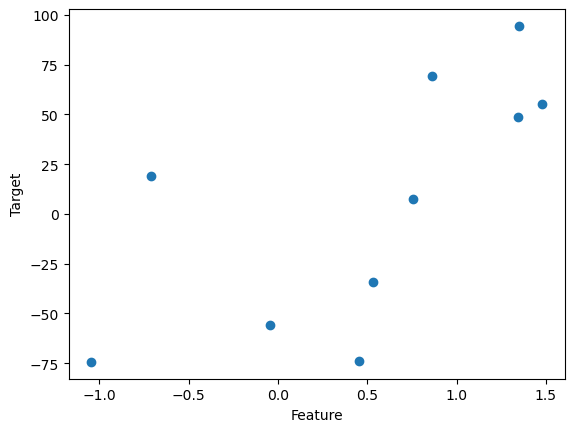

In [1]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

X,y = make_regression(n_samples=10, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)
plt.scatter(X,y)
plt.xlabel('Feature')
plt.ylabel('Target')
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [3]:
print(f'Coefficient: {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')

Coefficient: 48.53048883716478
Intercept: -18.45167109876422


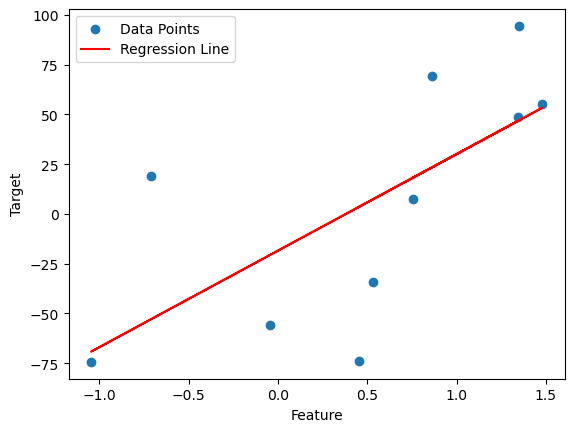

In [4]:
plt.scatter(X,y, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

In [5]:
# Lets apply Gradient Descent assuming slope is constant m = 48.53
# and let's assume the starting value for intercept b = 100
y_pred = ((48.53 * X) + 100).reshape(-1)

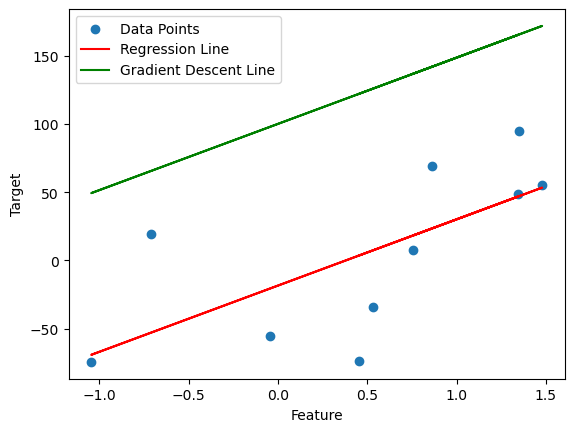

In [6]:
plt.scatter(X,y, label='Data Points')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.plot(X, y_pred, color='green', label='Gradient Descent Line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

In [7]:
m = 48.53
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

2369.028562119997

In [8]:
lr = 0.1

step_size = loss_slope*lr #Think loss slope as m since gradient  descent adjusts the m and c or b by this formula b(new) = b(old) - learning rate * m
step_size

236.9028562119997

In [9]:
b = b - step_size
b

-136.9028562119997

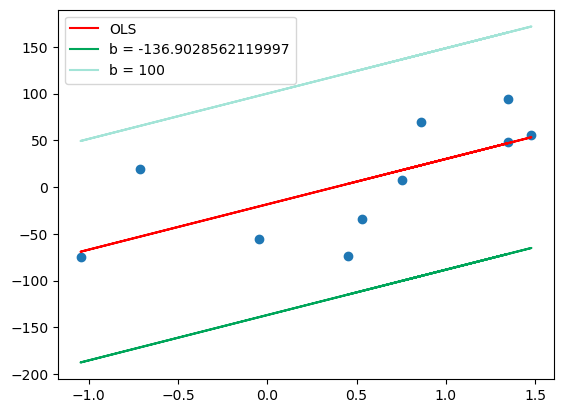

In [10]:
y_pred1 = ((48.53 * X) + b).reshape(-1)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 100')
plt.legend()
plt.show()

In [11]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-2369.028562119997

In [12]:
step_size = loss_slope*lr
step_size

-236.9028562119997

In [13]:
b = b - step_size
b

100.0

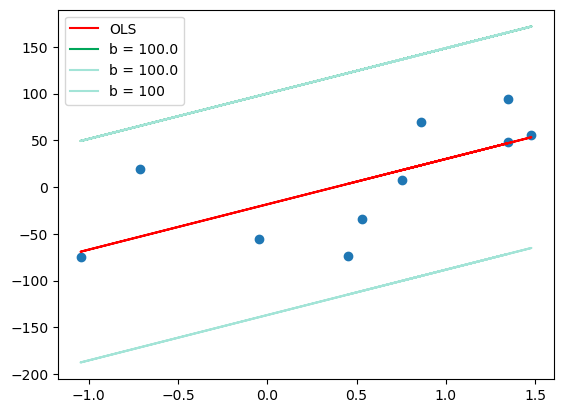

In [14]:
y_pred2 = ((48.53 * X) + b).reshape(-1)

plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 100')
plt.legend()
plt.show()

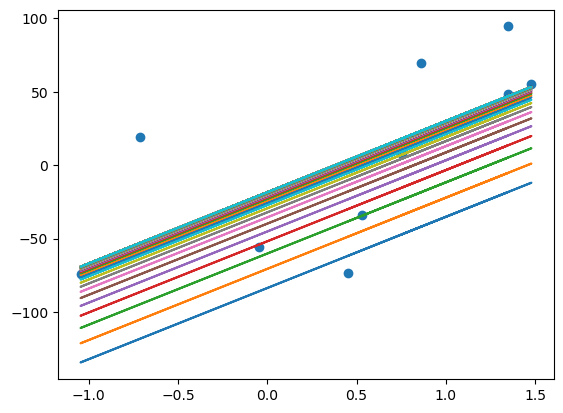

In [15]:
b = -100
m = 48.53
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)